# Phase 2 — ML EDA & Model Comparison

Loads `social_posts` from MySQL, shows class balance / split sizes, and (after a pipeline run) compares validation and test metrics for the three models.

In [1]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parents[1]
elif not (ROOT / "phase2").exists():
    ROOT = Path(r"d:\Social Media Sentiment & Brand Intelligence Platform")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from phase2.src.data import load_posts, make_splits, ARTIFACTS_DIR

sns.set_theme(style="whitegrid")
print("ROOT:", ROOT)

ROOT: d:\Social Media Sentiment & Brand Intelligence Platform


## Class balance

sentiment_group
Positive    499
Negative    215
Neutral      18
Name: count, dtype: int64

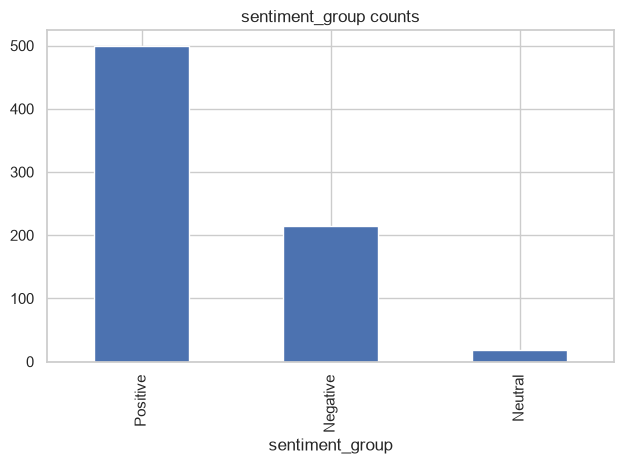

In [2]:
posts = load_posts()
display(posts["sentiment_group"].value_counts())
posts["sentiment_group"].value_counts().plot(kind="bar", title="sentiment_group counts")
plt.tight_layout()
plt.show()

## Stratified train / val / test sizes

In [3]:
split = make_splits(posts, random_state=42)
print(f"train={split.n_train} val={split.n_val} test={split.n_test}")
for name, y in [("train", split.y_train), ("val", split.y_val), ("test", split.y_test)]:
    print(f"\n{name}:")
    print(y.value_counts())

train=512 val=110 test=110

train:
sentiment_group
Positive    349
Negative    150
Neutral      13
Name: count, dtype: int64

val:
sentiment_group
Positive    75
Negative    32
Neutral      3
Name: count, dtype: int64

test:
sentiment_group
Positive    75
Negative    33
Neutral      2
Name: count, dtype: int64


## Comparison metrics (run pipeline first)

```bash
python -m phase2.src.pipeline_run --run-id v1
```

,model,val_f1_macro,test_f1_macro,test_accuracy
0,logreg_v1,0.608829,0.592758,0.900000
1,linearsvc_v1,0.617699,0.812840,0.900000
2,multinomialnb_v1,0.415819,0.466795,0.790909


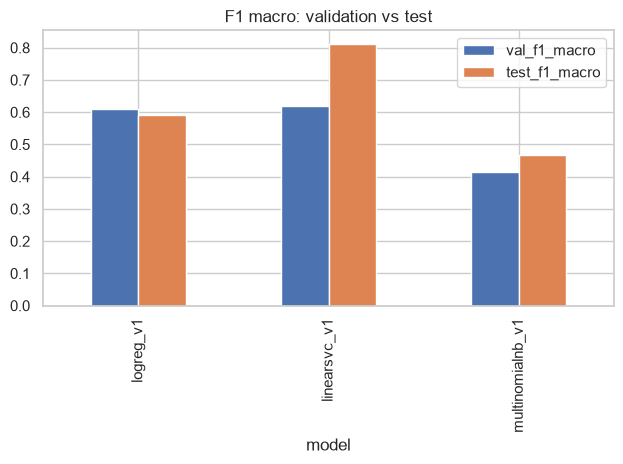

Best (val): linearsvc_v1


In [4]:
comp_path = ARTIFACTS_DIR / "comparison_v1.json"
eval_path = ARTIFACTS_DIR / "eval_summary_v1.json"

if comp_path.exists() and eval_path.exists():
    comparison = json.loads(comp_path.read_text(encoding="utf-8"))
    evaluation = json.loads(eval_path.read_text(encoding="utf-8"))

    rows = []
    for name, vm in comparison["models"].items():
        tm = evaluation["models"][name]["metrics"]
        rows.append({
            "model": name,
            "val_f1_macro": vm["val_f1_macro"],
            "test_f1_macro": tm["f1_macro"],
            "test_accuracy": tm["accuracy"],
        })
    dfm = pd.DataFrame(rows)
    display(dfm)

    dfm.set_index("model")[["val_f1_macro", "test_f1_macro"]].plot(
        kind="bar", title="F1 macro: validation vs test"
    )
    plt.tight_layout()
    plt.show()
    print("Best (val):", comparison.get("best_model_version"))
else:
    print("Artifacts not found. Run: python -m phase2.src.pipeline_run --run-id v1")